<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
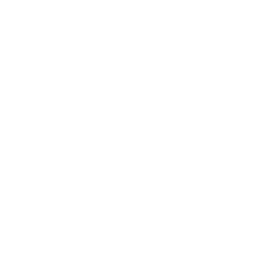
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">カリキュラム類似度分析</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 高等教育／学術プログラム設計 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

このノートブックは、**PROC DISTANCE** と **METHOD=DJACCARD**――バイナリの
有無データに自然な距離である Jaccard *非類似度* 係数――を用いて、大学の
講義カタログ全体でカリキュラムの重複を測定する。各講義は、どの認証学習
成果をカバーしているかを示す 40 個のバイナリフラグを持つため、2 つの講義
間の Jaccard 距離は、両者が共通して **持たない** カバー成果の割合となる
（0 = 成果集合が同一、1 = 共通成果なし）。

分析は 2 部構成である。まず、100 講義のカタログ全体について、学部別の
成果カバー幅をプロファイルし（PROC MEANS、PROC FREQ、カバレッジの箱ひげ
図）、ある学部でどの講義も **カバーしていない** 学習成果（カバレッジの
ギャップ）を洗い出す。次に、量的に最も重複する 2 学部――統計学とデータ
サイエンス――から抽出した 10 講義の絞り込みパネルへ掘り下げ、全ペアの
Jaccard 距離行列を計算し、統合レビュー候補として最も近い講義ペアをランク
付けする。目的は、カリキュラム委員会に 2 つの具体的な成果物を提供する
ことである：最も類似する講義のランキングと、学部×成果のギャップマップで
ある。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | 講義ごとのバイナリ学習成果カバレッジ（40 の成果フラグ） | 100 |
| WORK.PANEL10 | 統計学＋データサイエンスの統合パネル | 10 |

カタログは合成データである。成果フラグは学部固有の確率で抽出されており、
分野ごとに異なる成果クラスタを重視する（コンピュータサイエンスと数学は
前半の成果を、実験系科学は中間帯の成果を重み付けする）ため、距離分析に
現実的な構造が生まれる。この環境はライセンスなしで動作するため、作業用
カタログは 100 講義に制限されている。

---

In [1]:
/* --------------------------------------------------------
   合成的な講義×学習成果マトリクスを生成
   500 講義 × 40 の認証学習成果
   （ライセンスなしモードでは先頭 100 講義を保持）
   -------------------------------------------------------- */
データ work.course_outcomes;
    呼出 streaminit(42);
    配列 outcomes[40] lo_1 - lo_40;
    繰返 course_id = 1 から 500;
        course_label = cat('CRS', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        長さ department $30;
        もし dept_idx = 1 なら department = 'コンピュータ科学';
        他 もし dept_idx = 2 なら department = '数学';
        他 もし dept_idx = 3 なら department = '統計学';
        他 もし dept_idx = 4 なら department = '工学';
        他 もし dept_idx = 5 なら department = '生物学';
        他 もし dept_idx = 6 なら department = '化学';
        他 もし dept_idx = 7 なら department = '物理学';
        他 department = 'データサイエンス';
        /* 講義レベルが成果の幅に影響する */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* 学部固有の成果クラスタ */
        繰返 lo = 1 から 40;
            base_prob = 0.15;
            /* 学部 1-2（CS, 数学）：成果 1-15 を重視 */
            もし dept_idx <= 2 かつ lo <= 15 なら
                base_prob = 0.4 + course_level * 0.05;
            /* 学部 3-4（統計, 工学）：成果 10-25 を重視 */
            他 もし dept_idx IN (3, 4) かつ 10 <= lo <= 25 なら
                base_prob = 0.35 + course_level * 0.05;
            /* 学部 5-7（生物, 化学, 物理）：成果 20-35 を重視 */
            他 もし dept_idx IN (5, 6, 7) かつ 20 <= lo <= 35 なら
                base_prob = 0.38 + course_level * 0.04;
            /* 学部 8（データサイエンス）：広範なカバレッジ */
            他 もし dept_idx = 8 なら
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        終了;
        出力;
    終了;
    削除 dept_idx course_level base_prob lo;
実行;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  1.88 seconds
  cpu   1.88 seconds


In [2]:
/* --------------------------------------------------------
   講義カタログのメタデータを生成
   -------------------------------------------------------- */
データ work.course_catalog;
    呼出 streaminit(43);
    配列 format_list[3] $10 _temporary_ ('LECTURE' 'LAB' 'SEMINAR');
    繰返 course_id = 1 から 500;
        course_label = cat('CRS-', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        長さ department $30;
        もし dept_idx = 1 なら department = 'コンピュータ科学';
        他 もし dept_idx = 2 なら department = '数学';
        他 もし dept_idx = 3 なら department = '統計学';
        他 もし dept_idx = 4 なら department = '工学';
        他 もし dept_idx = 5 なら department = '生物学';
        他 もし dept_idx = 6 なら department = '化学';
        他 もし dept_idx = 7 なら department = '物理学';
        他 department = 'データサイエンス';
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        出力;
    終了;
    削除 dept_idx format_idx;
    書式 last_offered date9.;
実行;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.12 seconds
  cpu   0.12 seconds


---

                                                   学部別の学習成果カバレッジ（平均）                                                    

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                                   N
                                     学部                          Obs           Mean
                                     ----------------------------------------------
                                     コンピュータ科学                     13      0.3846154
                                     データサイエンス                     14      0.1428571
                                     化学                           19      0.2105263
                                     工学                           17      0.0000000
                                     数学                            9      0.6666667
                                     物理学                           7      0.2


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


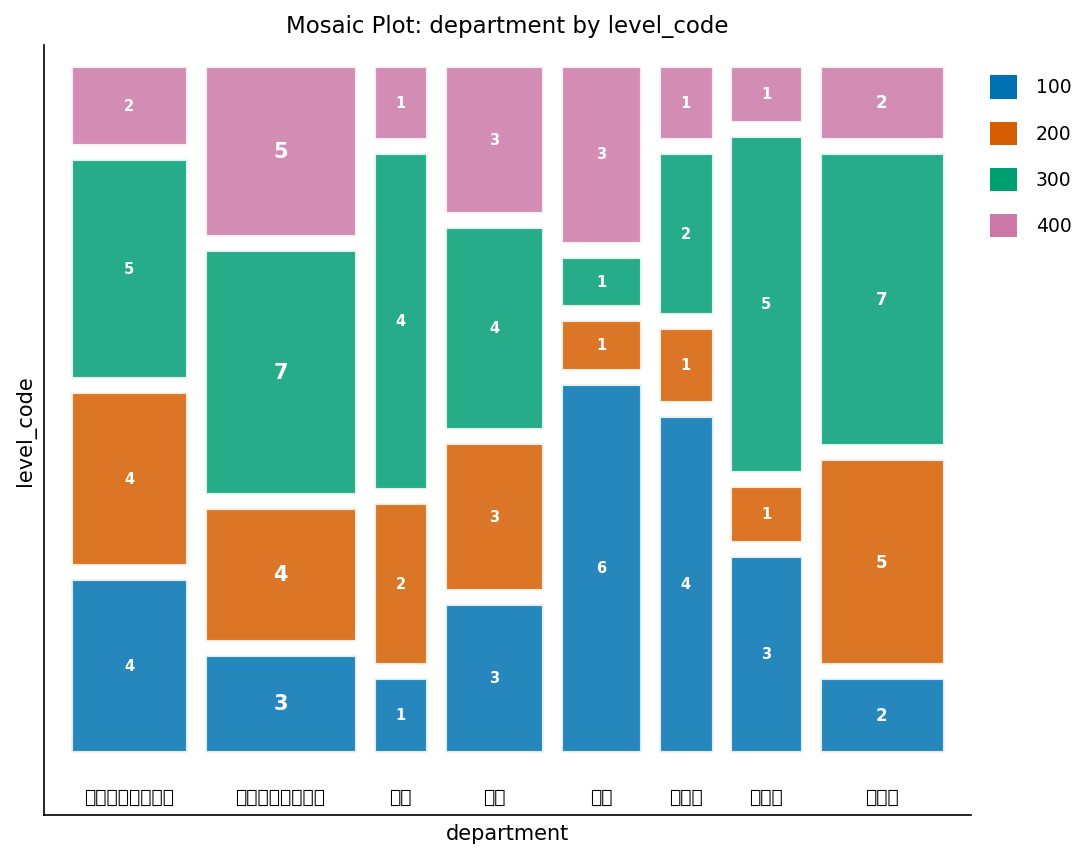

In [3]:
/* --------------------------------------------------------
   学部別の学習成果カバレッジのベースライン
   -------------------------------------------------------- */
処理 平均 データ=work.course_outcomes mean;
    分類 department;
    変数 lo_1 - lo_40;
    見出 department='学部';
    表題 '学部別の学習成果カバレッジ（平均）';
実行;

処理 度数 データ=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
    見出 department='学部' level_code='講義レベル';
    表題 '学部 × 講義レベルの分布';
実行;

---

                                                     学部 × 講義レベルの分布                                                      




NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 46 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


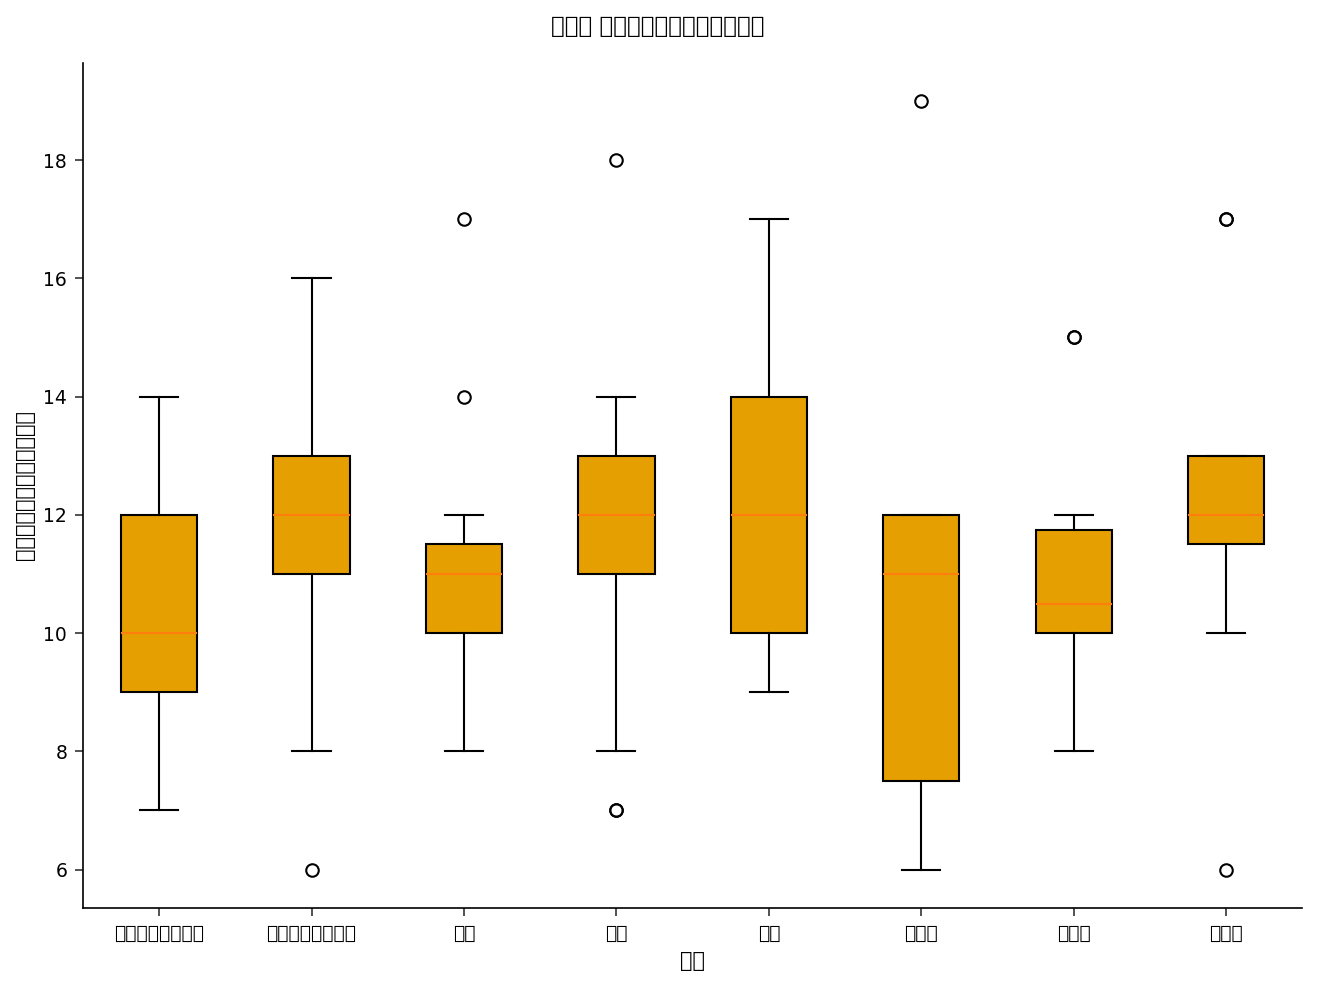

In [4]:
/* --------------------------------------------------------
   学部別の成果カバレッジ密度
   -------------------------------------------------------- */
データ work.outcome_counts;
    設定 work.course_outcomes;
    配列 outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
    見出 total_outcomes='カバーされた学習成果の数' department='学部';
実行;

処理 SGPLOT データ=work.outcome_counts;
    VBOX total_outcomes / category=department;
    YAXIS 見出='カバーされた学習成果の数';
    XAXIS 見出='学部';
    表題 '学部別 学習成果カバレッジの分布';
実行;

---

In [5]:
/* --------------------------------------------------------
   統合パネル：統計学／データサイエンス（量的に最も重複する
   2 学部）の先頭 10 講義。連番カウンタで P01-P10 に付け直し、
   正方の OUT= 距離行列がクリーンで参照しやすい列を持つように
   してから、METHOD=DJACCARD で全ペアの Jaccard 距離行列を
   計算する（0 = 成果集合が同一、1 = 共通成果なし）。
   -------------------------------------------------------- */
データ work.panel10;
    設定 work.course_outcomes(条件=(department IN ('統計学' 'データサイエンス')));
    保存 seq 0;
    seq + 1;
    もし seq > 10 なら 停止;
    panel_id = cat('P', PUT(seq, z2.));
    削除 seq;
実行;

処理 印刷 データ=work.panel10 noobs 見出;
    変数 panel_id course_label department level_code;
    見出 panel_id = 'パネルID' course_label = '講義'
          department = '学部' level_code = 'レベル';
    表題 '統合パネル：統計学とデータサイエンスの講義';
実行;

処理 distance データ=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    変数 nominal(lo_1 - lo_40);
    id panel_id;
実行;

処理 印刷 データ=work.panel_dist noobs;
    表題 'ペアワイズ Jaccard 距離行列（10 講義）';
実行;

                                                 統合パネル：統計学とデータサイエンスの講義                                                  

      パネルID       講義                        学部        レベル
P01          CRS0003  データサイエンス                        300
P02          CRS0006  統計学                             300
P03          CRS0014  データサイエンス                        300
P04          CRS0015  統計学                             300
P05          CRS0017  統計学                             200
P06          CRS0019  データサイエンス                        100
P07          CRS0022  統計学                             400
P08          CRS0033  データサイエンス                        200
P09          CRS0038  統計学                             100
P10          CRS0040  統計学                             100

                                                 統合パネル：統計学とデータサイエンスの講義                                                  

                                               ペアワイズ Jaccard 距離行列（10 講義）                                             


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 46 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   正方の距離行列を、講義ペアのランク付きリストへ再構成する。
   OUT= の距離列は明示的な名前リスト（P01 P02 ... P10）で参照し、
   厳密上三角（col > row）のみを残すことで、各無順序ペアが 1 回
   だけ現れ、ゼロ対角はスキップされる。最も近い 5 ペアが統合
   レビュー候補となる。
   -------------------------------------------------------- */
データ work.similar_courses;
    設定 work.panel_dist;
    配列 d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    長さ course_a course_b $8;
    course_a = _name_;
    row + 1;
    繰返 col = 1 から 10;
        もし col > row なら 繰返;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            出力;
        終了;
    終了;
    保持 course_a course_b jaccard_dist;
実行;

処理 平均 データ=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    変数 jaccard_dist;
    見出 jaccard_dist='Jaccard 距離';
    表題 'ペアワイズ Jaccard 距離の分布（45 講義ペア）';
実行;

処理 並替 データ=work.similar_courses; 基準 jaccard_dist; 実行;

データ work.top_pairs;
    設定 work.similar_courses;
    pair_rank = _n_;
    もし pair_rank <= 5;
実行;

処理 印刷 データ=work.top_pairs noobs 見出;
    変数 pair_rank course_a course_b jaccard_dist;
    見出 pair_rank = 'ランク' course_a = '講義A'
          course_b = '講義B' jaccard_dist = 'Jaccard 距離';
    表題 '最も近い 5 つの講義ペア（統合候補）';
実行;

                                              ペアワイズ Jaccard 距離の分布（45 講義ペア）                                              

                                                  The MEANS Procedure

 Variable      Label                 N     Minimum   Lower Quartile      Median        Mean     Maximum
 ------------------------------------------------------------------------------------------------------
 jaccard_dist  Jaccard 距離           45       0.588            0.762       0.826       0.818       0.962
 ------------------------------------------------------------------------------------------------------

                                                  最も近い 5 つの講義ペア（統合候補）                                                   

      ランク      講義A      講義B      Jaccard 距離
        1  P02      P10               0.588
        2  P03      P04                 0.6
        3  P03      P05               0.667
        4  P02      P04               0.684
        5  P02      P07               0.684




NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                                     学部ごとの未カバー学習成果                                                      

                                                   The FREQ Procedure

学部                          Frequency    Percent
-------------------------------------------------
コンピュータ科学                            3     10.00
化学                                  2      6.67
工学                                  2      6.67
数学                                  4     13.33
物理学                                 8     26.67
生物学                                 8     26.67
統計学                                 3     10.00
                                               成果ギャップのサンプル（30 件中の先頭 12 件）                                               

                      学部              未カバー成果
コンピュータ科学                  LO29
コンピュータ科学                  LO35
コンピュータ科学                  LO36
化学                        LO02
化学                        LO12
工学                        LO01
工学                 


NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


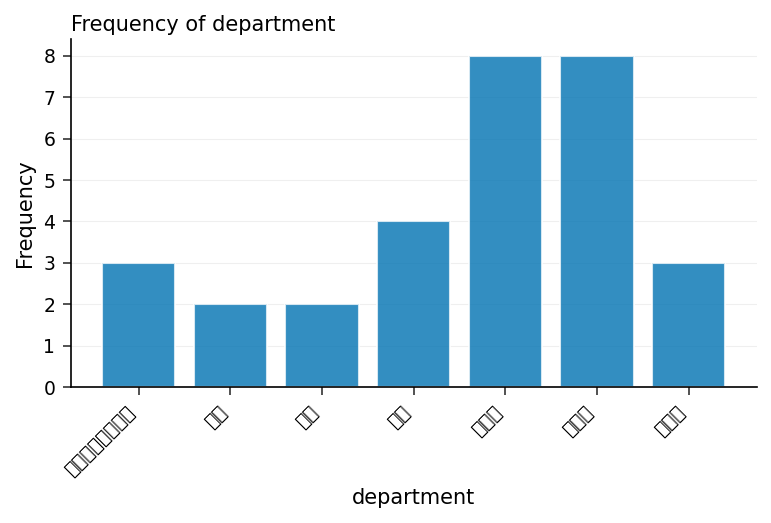

In [7]:
/* --------------------------------------------------------
   成果ギャップ：ある学部のどの講義もカバーしていない学習成果。
   PROC MEANS が学部内で各バイナリ成果フラグを合計し、合計が
   ゼロならその成果は当該学部のカタログに存在しない。
   -------------------------------------------------------- */
処理 平均 データ=work.course_outcomes sum NOPRINT;
    分類 department;
    変数 lo_1 - lo_40;
    出力 out=work.dept_coverage(条件=(_type_=1))
        sum=lo_1 - lo_40;
実行;

データ work.outcome_gaps;
    設定 work.dept_coverage;
    配列 outcomes[40] lo_1 - lo_40;
    繰返 lo = 1 から 40;
        outcome_id = cat('LO', PUT(lo, z2.));
        courses_covering = outcomes[lo];
        もし courses_covering = 0 なら 繰返;
            gap_flag = 1;
            出力;
        終了;
    終了;
    保持 department outcome_id courses_covering gap_flag;
実行;

処理 度数 データ=work.outcome_gaps;
    TABLES department / nocum;
    見出 department='学部';
    表題 '学部ごとの未カバー学習成果';
実行;

処理 印刷 データ=work.outcome_gaps(obs=12) noobs 見出;
    変数 department outcome_id;
    見出 department = '学部' outcome_id = '未カバー成果';
    表題 '成果ギャップのサンプル（30 件中の先頭 12 件）';
実行;

---

### 解釈

**統合パネル。** 10 講義の統計学／データサイエンスパネルにおける 45 個の
無順序ペア全体で、Jaccard 距離は 0.588 から 0.962 まで分布し、中央値
0.826（平均 0.818）である。最も近いペアは距離 0.588 の P02 と P10 で、
続いて P03–P04 が 0.600、P03–P05 が 0.667 である。最も類似する講義でさえ、
カバー成果のおよそ 59% で異なるため、このカタログには **ほぼ重複する
講義は存在しない**――委員会がそのまま統合できるペアはない。むしろこの
ランキングは、次のカタログ改訂の前に手作業でシラバスを比較する価値の
ある少数のペアを指し示す。距離が最も高いペア（0.962 付近）は、統計学と
データサイエンスの講義が同じ学部圏を共有しながらも、真に異なる成果集合
にまたがることを裏付ける。

**成果ギャップ。** カタログ全体で 30 個の学部×成果ギャップが浮上する。
実験の多い分野が最も多く抱える：**生物学** と **物理学** はそれぞれ
40 の認証成果のうち 8 個を未カバーのまま残し、続いて **数学**（4 個）
である。量的な学部が最もよくカバーしており――**化学** と
**工学** はそれぞれ 2 個しか取りこぼしていない。これらのギャップは、
新規講義の開発やクロスリスティングの自然な対象である：学部全体で欠けて
いる成果は認証更新時のカバレッジリスクであり、一方で統合リストは重複した
労力という逆の問題に対処する。2 つの成果物を合わせることで、委員会は 1 つ
の集合ベースの距離尺度を用いて、重複を削り、空白を埋めるという両端から
カタログを引き締められる。

---

In [8]:
/* --------------------------------------------------------
   カリキュラム委員会向けに、ランク付き統合候補と
   学部別の成果ギャップマップをエクスポートする。
   -------------------------------------------------------- */
処理 EXPORT データ=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
実行;

処理 EXPORT データ=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
実行;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供： <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>